# **Load and Preprocess the MNIST Dataset**

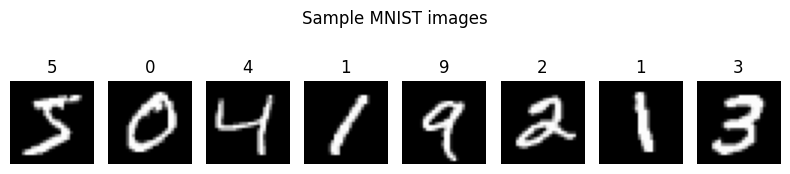

In [4]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# To remove randomness
tf.random.set_seed(42)
np.random.seed(42)

# Loaing the MNIST dataset
(X_train, y_train), (X_test,  y_test) = mnist.load_data()

# Scaling images to [0,1]
X_train = X_train.astype("float32") / 255.0
Y_train = y_train.astype("float32") / 255.0

# One-hot encoding labels
num_classes = 10
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh = to_categorical(y_test, num_classes)

# Looking at a few smaples
plt.figure(figsize=(8,2))
for i in range(8):
  plt.subplot(1,8, i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(int(y_train[i]))
  plt.axis("off")
plt.suptitle("Sample MNIST images")
plt.tight_layout()
plt.show()


# **Build a Fully Connected Neural Network**

In [6]:
# Building the model (densed network)
model = models.Sequential([
   layers.Flatten(input_shape=(28,28)), # Input layer
   layers.Dense(128,activation="relu"), # Hidden layer
   layers.Dense(64,activation="relu"), # Hidden layer
   layers.Dense(num_classes, activation="softmax") # Output layer
])


# Compiling the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# **Train the Neural Network**

In [8]:
# Training the model
history = model.fit(
    X_train, y_train_oh,
    epochs=10,                # you can increase for better accuracy
    batch_size=128,          # how many images to work with then updating step
    validation_split=0.1,     # keeping 10% of training data to monitor validation performance \
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8176 - loss: 0.6670 - val_accuracy: 0.9613 - val_loss: 0.1370
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9524 - loss: 0.1634 - val_accuracy: 0.9680 - val_loss: 0.1067
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9672 - loss: 0.1120 - val_accuracy: 0.9707 - val_loss: 0.0984
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9765 - loss: 0.0826 - val_accuracy: 0.9718 - val_loss: 0.0946
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9815 - loss: 0.0641 - val_accuracy: 0.9727 - val_loss: 0.0940
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9862 - loss: 0.0502 - val_accuracy: 0.9715 - val_loss: 0.0932
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9895 - loss: 0.0393 - val_accuracy: 0.9743 - val_loss: 0.0961
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9925 - loss: 0.0311 - val_accuracy: 0.

Test Accuracy: 0.9708


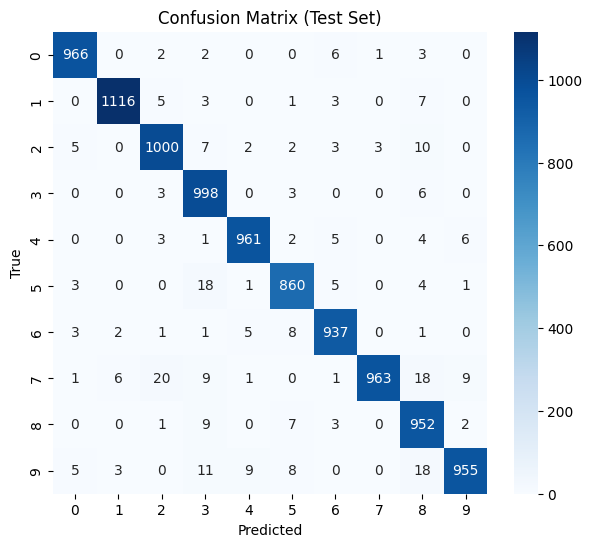

Per-class accuracy: [0.986 0.983 0.969 0.988 0.979 0.964 0.978 0.937 0.977 0.946]
Hardest digits (lowest accuracy): [7, 9, 5]

Classification report:

              precision    recall  f1-score   support

           0      0.983     0.986     0.984       980
           1      0.990     0.983     0.987      1135
           2      0.966     0.969     0.968      1032
           3      0.942     0.988     0.965      1010
           4      0.982     0.979     0.980       982
           5      0.965     0.964     0.965       892
           6      0.973     0.978     0.976       958
           7      0.996     0.937     0.965      1028
           8      0.931     0.977     0.953       974
           9      0.982     0.946     0.964      1009

    accuracy                          0.971     10000
   macro avg      0.971     0.971     0.971     10000
weighted avg      0.971     0.971     0.971     10000



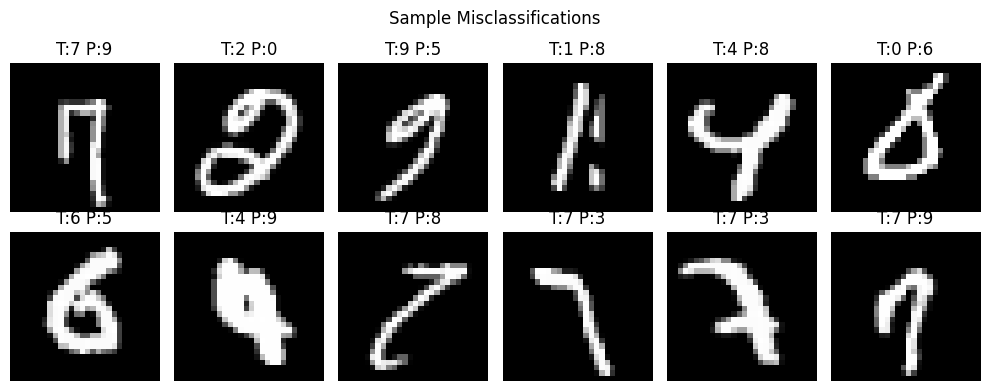

In [10]:
# # Plot training curves (loss & accuracy)
# fig, ax = plt.subplots(1,2, figsize=(12,4))

# ax[0].plot(history.history["loss"], label="train loss")
# ax[0].plot(history.history["val_loss"], label="val loss")
# ax[0].set_title("Loss")
# ax[0].legend()

# ax[1].plot(history.history["accuracy"], label="train acc")
# ax[1].plot(history.history["val_accuracy"], label="val acc")
# ax[1].set_title("Accuracy")
# ax[1].legend()

# plt.tight_layout()
# plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix on test set
#     - Get predicted labels
pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Which digits are hardest? (per-class accuracy)
per_class_acc = (cm.diagonal() / cm.sum(axis=1))
hardest_idx = np.argsort(per_class_acc)[:3]  # 3 worst classes
print("Per-class accuracy:", np.round(per_class_acc, 3))
print("Hardest digits (lowest accuracy):", hardest_idx.tolist())

# Quick classification report (precision/recall/F1 per digit)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Visualize a few mistakes
mistakes = np.where(y_pred != y_test)[0]
if len(mistakes) > 0:
    sample = np.random.choice(mistakes, size=min(12, len(mistakes)), replace=False)
    plt.figure(figsize=(10,4))
    for i, idx in enumerate(sample):
        plt.subplot(2,6,i+1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
        plt.axis("off")
    plt.suptitle("Sample Misclassifications")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found (unlikely), try fewer epochs or a smaller model.")